In [13]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END, add_messages
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.checkpoint.memory import InMemorySaver

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool

import requests
import random


os.environ['LANGCHAIN_PROJECT']= "LangGraph-tools-call"

load_dotenv()


True

In [14]:
model= ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    api_key=os.getenv("GROQ_API_KEY")
)

In [39]:
# Tools

# prebuild tool
search_tool= DuckDuckGoSearchRun(region='us-en')


# custom tools
@tool
def calculator(first_num:float, second_num:float, operation:str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: addition(add), substraction(sub), multiplication(mul), division(div)
    """
    try:
        if operation=='add':
            result= first_num+ second_num

        elif operation=='sub':
            result= first_num-second_num

        elif operation=='mul':
            result= first_num* second_num
        elif operation=='div':
            if second_num==0:
                result= {"error":"division by zero is not allowed"}
            result= first_num/second_num
        else:
            return {"error":f"Unsupported operation '{operation}'"}
        return {"first_num":first_num, "second_num":second_num, "operation":operation, "result":result}
    
    except Exception as e:
        return {"error": str(e)}
    

@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. "AAPL", "TSLA")
    using Alpha Vantage with API key in the URL.
    """
    url= f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={os.getenv('STOCK_API_KEY')}"
    r= requests.get(url)
    return r.json()


In [40]:
# Make tool list
tools= [get_stock_price, search_tool, calculator]

# Make the LLM tools-aware
llm_with_tools= model.bind_tools(tools)

In [41]:
class QuesAnsState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [42]:
def QuesAnsNode(state:QuesAnsState):
    """ LLM node that may answer or request a tools call. """
    messages= [SystemMessage(content="You are a QUESTION-ANSWER assistent.And answer only if you know other-wise explicitly tell you don't know!"), *state['messages']]

    # prompt= ChatPromptTemplate.from_messages(messages)
    # parser= StrOutputParser()
    # QuesAnsChain = prompt|llm_with_tools|parser


    result= llm_with_tools.invoke(messages)

    return {"messages":[result]}


tool_node= ToolNode(tools) # Executes tool calls

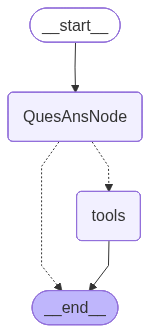

In [31]:
builder= StateGraph(QuesAnsState)

builder.add_node('QuesAnsNode', QuesAnsNode)
builder.add_node('tools', tool_node)

builder.add_edge(START, 'QuesAnsNode')

# so tools_condition parest inside that QuesAnsNode and check that node is asking for tools call  if the LLM asked for a tool , go to ToolNode; else finish (END) ; by defaul behaviour
builder.add_conditional_edges("QuesAnsNode", tools_condition)


# checkpointer= InMemorySaver()

graph= builder.compile()
graph


In [32]:
# config= {
#     "configurable":{"thread_id":1},
#     "metadata":{"thread_id":1},
#     "run_name":"langGraph_tools"
# }

result= graph.invoke({"messages":[HumanMessage(content="what is 2+3")]})

In [33]:
print( result)

{'messages': [HumanMessage(content='what is 2+3', additional_kwargs={}, response_metadata={}, id='c303f22a-eeb8-4f6a-8215-d5bcf0524cae'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '4fxnc6zav', 'function': {'arguments': '{"first_num":2,"operation":"add","second_num":3}', 'name': 'calculator'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 893, 'total_tokens': 937, 'completion_time': 0.099833361, 'completion_tokens_details': None, 'prompt_time': 0.033127571, 'prompt_tokens_details': None, 'queue_time': 0.051002529, 'total_time': 0.132960932}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3643-2455-7b91-8491-740c6e014bba-0', tool_calls=[{'name': 'calculator', 'args': {'first_num': 2, 'operation': 'add', 'second_num': 3}, 'id': '4fxnc6zav', 'type

In [34]:
result= graph.invoke({"messages":[HumanMessage(content="What is stock price of apple")]})
print(result)

{'messages': [HumanMessage(content='What is stock price of apple', additional_kwargs={}, response_metadata={}, id='40017a77-a76e-4e47-9a28-acb04b9b70b8'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ybnh59aec', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 893, 'total_tokens': 924, 'completion_time': 0.07074226, 'completion_tokens_details': None, 'prompt_time': 0.032951821, 'prompt_tokens_details': None, 'queue_time': 0.050684529, 'total_time': 0.103694081}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e364f-0b02-73e3-b2a2-44232b5a3498-0', tool_calls=[{'name': 'get_stock_price', 'args': {'symbol': 'AAPL'}, 'id': 'ybnh59aec', 'type': 'tool_call'}], invalid_tool_calls=[],

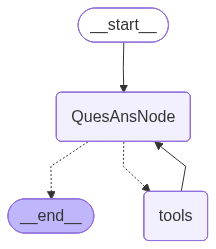

In [43]:
builder1= StateGraph(QuesAnsState)

builder1.add_node('QuesAnsNode', QuesAnsNode)
builder1.add_node('tools', tool_node)

builder1.add_edge(START, 'QuesAnsNode')

# so tools_condition parest inside that QuesAnsNode and check that node is asking for tools call  if the LLM asked for a tool , go to ToolNode; else finish (END) ; by defaul behaviour
builder1.add_conditional_edges("QuesAnsNode", tools_condition)

# now we should have a loop from 'tools' node to 'QuesAnsNode'
builder1.add_edge('tools', 'QuesAnsNode')



# checkpointer= InMemorySaver()

graph1= builder1.compile()
graph1

In [ ]:
# why we did that , take an eg ; run it see before we are getting direct tool output (json) now polic output from llm

result= graph1.invoke({'messages':[HumanMessage(content="what is 2 + 6")]})
print(result['messages'][-1].content)

The result of 2 + 6 is 8.


In [44]:
result= graph1.invoke({'messages':[HumanMessage(content="what is the stock price of apple. How much would it cost to purchase 50 share of apple")]})
print(result['messages'][-1].content)

The current stock price of Apple (AAPL) is $300.23.

To purchase 50 shares of Apple, it would cost approximately $15,011.50 (50 shares * $300.23 per share).
